In [3]:
# General purpose
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
# Dimensionality reduction
from sklearn.decomposition import PCA

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

## Constante

In [4]:
FILEPATH_MAT = "data/S2_A1_E1.mat"
FILEPATH_CSV = "data/data.csv"

TRAIN_PCT = .6
VAL_PCT = .2
TEST_PCT = .2
CV_K = round((TRAIN_PCT+VAL_PCT) / VAL_PCT)

assert TRAIN_PCT + VAL_PCT + TEST_PCT == 1.0, "Oh mein Gott, bist du dumm oder kannst du einfach nur nicht rechnen? Schonmal was von 1.0 gehört?"

REMAINING_TIME_BUFFER = 1.7

In [5]:
data = loadmat(FILEPATH_MAT)

print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
print("EMG data dimension: {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))

stimulus = data['stimulus']
repetition = data['repetition']

N_STIMULI = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
N_REPETITIONS = len(np.unique(repetition)) - 1 # -1 because 0 is not a repetition
N_CHANNELS = emg.shape[1]

Dataset variables:
['subject', 'exercise', 'stimulus', 'emg', 'glove', 'restimulus', 'repetition', 'rerepetition']
EMG data dimension: (100686, 10)
EMG data type: <class 'numpy.ndarray'>


## FEatures

In [6]:
# import pywt
import pywt
from scipy.fft import rfft, irfft

# Mean absolute value (MAV)
mav = lambda x: np.mean(np.abs(x), axis=0)
# Standard Deviation (STD)
std = lambda x: np.std(x, axis=0)
# Maximum absolute Value (MaxAV)
maxav = lambda x: np.max(np.abs(x), axis=0)
# Root mean square (RMS)
rms = lambda x: np.sqrt(np.mean(x**2, axis=0))
# Waveform length (WL)
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0)
# Slope sign changes (SSC)
ssc = lambda x: np.sum((np.diff(x, axis=0)[:-1, :] * np.diff(x, axis=0)[1:, :]) < 0, axis=0)

# Additional features from the paper:
# Zero Crossings (ZC) with threshold to reduce noise sensitivity
def zc(x, th=0.01):
    # x: (T, C)
    dx = x[:-1, :] * x[1:, :] # product of consecutive samples to find sign changes
    crossings = (dx < 0) & (np.abs(x[:-1, :]) > th) | (np.abs(x[1:, :]) > th) # check for sign change and threshold
    return np.sum(crossings, axis=0).astype(float)

# Willison Amplitude (WAMP) - counts of large amplitude differences
def wamp(x, th=0.02):
    return np.sum(np.abs(np.diff(x, axis=0)) > th, axis=0).astype(float)

# Simple FD features: mean frequency and median frequency per channel
def mean_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Psum = np.sum(Pxx, axis=0) + 1e-12
    return np.sum(f[:, None] * Pxx, axis=0) / Psum

def median_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Pcum = np.cumsum(Pxx, axis=0)
    total = Pcum[-1, :] + 1e-12
    med = np.zeros(x.shape[1])
    for c in range(x.shape[1]):
        idx = np.searchsorted(Pcum[:, c], total[c] / 2.0)
        med[c] = f[min(idx, f.size - 1)]
    return med


# --- Wavelet-energy feature (9 scales) ---
def wavelet_energy_9(x, wavelet="bior3.5", max_scales=9):
    """
    Compute energy of wavelet coefficients in up to 9 scales for each channel.
    Returns a 1D vector of length (n_channels * n_scales_used).
    
    x: (T, C) EMG segment
    """
    T, C = x.shape
    energies_per_channel = []

    for ch in range(C):
        sig = x[:, ch]

        # Multi-level discrete wavelet decomposition
        coeffs = pywt.wavedec(sig, wavelet=wavelet)

        # coeffs[0] = approximation, coeffs[1:] = detail coeffs
        # We take up to 'max_scales' detail levels (or fewer if not available).
        detail_coeffs = coeffs[1:]
        n_scales = min(len(detail_coeffs), max_scales)

        ch_energies = []
        for s in range(n_scales):
            c_s = detail_coeffs[s]
            ch_energies.append(np.sum(c_s**2))

        # If fewer than max_scales exist (short signals), pad with zeros
        if n_scales < max_scales:
            ch_energies.extend([0.0] * (max_scales - n_scales))

        energies_per_channel.append(ch_energies)

    energies_per_channel = np.array(energies_per_channel)  # (C, max_scales)
    return energies_per_channel.flatten()  # (C * max_scales,)


# --- Cepstrum feature (real cepstrum, first n_ceps coefficients per channel) ---
def cepstrum_coeffs(x, fs=100, n_ceps=4):
    """
    Real cepstrum per channel: take log-magnitude spectrum, IFFT,
    then keep first n_ceps coefficients (excluding index 0).
    Returns a 1D vector of length (n_channels * n_ceps).
    
    x: (T, C) EMG segment
    """
    T, C = x.shape
    ceps_per_channel = []

    eps = 1e-12
    for ch in range(C):
        sig = x[:, ch]

        # Real FFT
        Xf = rfft(sig)
        log_mag = np.log(np.abs(Xf) + eps)

        # Real cepstrum
        ceps = irfft(log_mag)

        # Take first n_ceps after c[0]
        n_keep = min(n_ceps, ceps.size - 1)
        ceps_per_channel.append(ceps[1 : 1 + n_keep])

        if n_keep < n_ceps:
            # Pad if too short (unlikely, but safe)
            pad = np.zeros(n_ceps - n_keep)
            ceps_per_channel[-1] = np.concatenate([ceps_per_channel[-1], pad])

    ceps_per_channel = np.array(ceps_per_channel)  # (C, n_ceps)
    return ceps_per_channel.flatten()  # (C * n_ceps,)



# Combine all features into a dict (keys are used later for selecting subsets)
all_features = {
    "mav": mav,
    "std": std,
    "maxav": maxav,
    "rms": rms,
    "wl": wl,
    "ssc": ssc,
    "zc": zc,
    "wamp": wamp,
    "mean_freq": mean_freq,
    "median_freq": median_freq,
    "wavelet_9": wavelet_energy_9,
    "cepstrum_coeffs": cepstrum_coeffs,
}

#TODO: Feel free to add more features, e.g. frequency domain features. (See https://doi.org/10.3390/s19204596 and https://doi.org/10.1088/0967-3334/24/2/307)

In [ ]:
from itertools import combinations

feature_names = list(all_features.keys())

# Generate all non-empty feature subsets
all_feature_sets = []
for r in range(1, len(feature_names) + 1):
    for combo in combinations(feature_names, r):
        all_feature_sets.append(combo)

print(f"Total number of feature subsets: {len(all_feature_sets)}")

max_feature_set = [all_feature_sets[-1]]
print(f"Total number of feature subsets: {len(max_feature_set)}")
print([set for set in max_feature_set])

## BUild Dataset

In [8]:
def build_dataset_from_ninapro(emg, stimulus, repetition, features):
    """
    Build a (n_trials, n_total_features) dataset from Ninapro data.

    - emg:        (n_samples, n_channels)
    - stimulus:   (n_samples, 1)
    - repetition: (n_samples, 1)
    - features:   iterable of feature functions

    Each feature function must take emg_window (T, n_channels) and return
    a 1D array-like of length >= 1 (can be > n_channels).
    """

    stimulus = stimulus.ravel()
    repetition = repetition.ravel()
    n_channels = emg.shape[1]

    unique_stimuli = np.unique(stimulus)
    unique_stimuli = unique_stimuli[unique_stimuli > 0]   # ignore rest (0)
    unique_reps = np.unique(repetition)
    unique_reps = unique_reps[unique_reps > 0]

    n_trials = len(unique_stimuli) * len(unique_reps)

    # ---- determine feature dimensions from a single example window ----
    # pick first non-empty trial as example
    example_feat_dims = []
    for feat in features:
        example_feat_dims.append(None)  # placeholder
    # find an example window
    for s in unique_stimuli:
        for r in unique_reps:
            mask = (stimulus == s) & (repetition == r)
            if np.any(mask):
                emg_example = emg[mask, :]
                # now actually compute dims
                example_feat_dims = []
                for feat in features:
                    out = np.asarray(feat(emg_example)).ravel()
                    example_feat_dims.append(out.size)
                break
        else:
            continue
        break

    total_feature_dim = int(np.sum(example_feat_dims))

    # ---- allocate dataset + labels ----
    dataset = np.zeros((n_trials, total_feature_dim), dtype=float)
    labels = np.zeros(n_trials, dtype=int)

    # ---- fill dataset ----
    trial_idx = 0
    for s in unique_stimuli:
        for r in unique_reps:
            mask = (stimulus == s) & (repetition == r)
            if not np.any(mask):
                continue

            emg_window = emg[mask, :]
            labels[trial_idx] = s  # movement label

            current_feature_index = 0
            for feat, feat_dim in zip(features, example_feat_dims):
                feat_vec = np.asarray(feat(emg_window)).ravel()
                if feat_vec.size != feat_dim:
                    raise ValueError(
                        f"Feature output size changed between trials: "
                        f"expected {feat_dim}, got {feat_vec.size}"
                    )

                selected_features = np.arange(
                    current_feature_index,
                    current_feature_index + feat_dim
                )
                dataset[trial_idx, selected_features] = feat_vec
                current_feature_index += feat_dim

            trial_idx += 1

    # If some trials were empty and skipped, trim the arrays
    dataset = dataset[:trial_idx]
    labels = labels[:trial_idx]

    return dataset, labels


## Train Val Test Split

In [9]:

# Build full dataset ONCE (using all features)
dataset, labels = build_dataset_from_ninapro(emg, stimulus, repetition, all_features.values())

# Fixed train/val/test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    dataset, 
    labels, 
    test_size=TEST_PCT, 
    random_state=RANDOM_STATE, 
    stratify=labels,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 72 samples
Validation set size: 24 samples
Test set size: 24 samples


## Classification

### Step 1: Initial Hyperparameter Tuning on All Features

In [11]:
# ==================================================
# Hyperparameter Grid Search on ALL FEATURES
# To find good baseline hyperparameters for feature selection
# ==================================================

from sklearn.model_selection import GridSearchCV

print("Step 1: Finding optimal hyperparameters on all features...")
print(f"Total features: {X_trainval.shape[1]}")

pipeline_initial = Pipeline([
    ("scaler", StandardScaler()),
    ("gbc", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "gbc__n_estimators": [50, 100, 200, 300],
    "gbc__learning_rate": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "gbc__max_depth": [2, 3, 4],
    "gbc__subsample": [0.8, 1.0],
    # "gbc__min_samples_split": [2, 5, 10],
}

kfold = KFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)

grid_search_initial = GridSearchCV(
    estimator=pipeline_initial,
    param_grid=param_grid,
    scoring="accuracy",
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_search_initial.fit(X_trainval, y_trainval)

print("\n" + "="*60)
print("INITIAL HYPERPARAMETER SEARCH RESULTS (All Features)")
print("="*60)
print("Best parameters:", grid_search_initial.best_params_)
print(f"Best CV accuracy: {grid_search_initial.best_score_:.4f}")
print("="*60)

# Store the best hyperparameters for use in feature selection
best_params_initial = {
    k.replace("gbc__", ""): v 
    for k, v in grid_search_initial.best_params_.items()
}

print(f"\nThese hyperparameters will be used for feature selection loop.")


Step 1: Finding optimal hyperparameters on all features...
Total features: 230
Fitting 4 folds for each of 144 candidates, totalling 576 fits

INITIAL HYPERPARAMETER SEARCH RESULTS (All Features)
Best parameters: {'gbc__learning_rate': 0.05, 'gbc__max_depth': 3, 'gbc__n_estimators': 100, 'gbc__subsample': 0.8}
Best CV accuracy: 0.7188

These hyperparameters will be used for feature selection loop.


### Step 2: Feature Selection Using Tuned Hyperparameters

In [127]:
# ==================================================
# Loop over feature subsets with CROSS-VALIDATION (trainval only)
# Using hyperparameters tuned on all features
# ==================================================

print("Step 2: Testing all feature subsets with tuned hyperparameters...")
print(f"Using hyperparameters: {best_params_initial}")

# Create pipeline with the tuned hyperparameters from Step 1
pipeline_feature_search = Pipeline([
    ("scaler", StandardScaler()),
    ("gbc", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **best_params_initial
    ))
])

feature_set = all_feature_sets

cv_results = []   # store cross-validation results
t0 = time.time()

kfold = KFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)

for i, subset in enumerate(feature_set):

    # ---- Map feature names to the correct columns ----
    feature_indices = []
    for fname in subset:
        idx = list(all_features.keys()).index(fname)
        start_col = idx * n_channels
        end_col = start_col + n_channels
        feature_indices.extend(range(start_col, end_col))

    # ---- Subset TRAINVAL directly ----
    X_trainval_sub = X_trainval[:, feature_indices]

    # ---- Cross-validation ----
    scores = cross_val_score(
        pipeline_feature_search,
        X_trainval_sub,
        y_trainval,
        cv=kfold,
        scoring="accuracy"
    )

    mean_acc = scores.mean()
    std_acc  = scores.std()

    cv_results.append({
        "feature_set": subset,
        "cv_accuracy": mean_acc,
        "cv_std": std_acc,
        "feature_indices": feature_indices
    })

    # ---- Progress display ----
    elapsed = time.time() - t0
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(feature_set) - i - 1) * REMAINING_TIME_BUFFER

    print(
        f"completed {i+1}/{len(feature_set)} | remaining: "
        f"{time.strftime('%H:%M:%S', time.gmtime(remaining))} | "
        f"CV acc={mean_acc:.4f} | {subset}"
        + " " * 50,
        end="\r"
    )

print("\nCross-validation search done.")

# ==================================================
# Determine best feature set based on CV accuracy
# ==================================================

best_entry = max(cv_results, key=lambda r: r["cv_accuracy"])
best_subset = best_entry["feature_set"]
best_cv_acc = best_entry["cv_accuracy"]

print(f"\n{'='*60}")
print(f"BEST FEATURE SET FOUND")
print(f"{'='*60}")
print(f"Features: {best_subset}")
print(f"CV accuracy: {best_cv_acc:.4f}")
print(f"{'='*60}")

# ==================================================
# Extract best features for final hyperparameter tuning
# ==================================================

best_feature_indices = best_entry["feature_indices"]

X_trainval_sub = X_trainval[:, best_feature_indices]
X_test_sub     = X_test[:, best_feature_indices]

print(f"\nProceeding to Step 3: Fine-tuning hyperparameters on best feature subset...")


Step 2: Testing all feature subsets with tuned hyperparameters...
Using hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
completed 4095/4095 | remaining: 00:00:00 | CV acc=0.7083 | ('mav', 'std', 'maxav', 'rms', 'wl', 'ssc', 'zc', 'wamp', 'mean_freq', 'median_freq', 'wavelet_9', 'cepstrum_coeffs')                                                  
Cross-validation search done.

BEST FEATURE SET FOUND
Features: ('mav', 'std', 'maxav', 'rms')
CV accuracy: 0.8125

Proceeding to Step 3: Fine-tuning hyperparameters on best feature subset...
completed 4095/4095 | remaining: 00:00:00 | CV acc=0.7083 | ('mav', 'std', 'maxav', 'rms', 'wl', 'ssc', 'zc', 'wamp', 'mean_freq', 'median_freq', 'wavelet_9', 'cepstrum_coeffs')                                                  
Cross-validation search done.

BEST FEATURE SET FOUND
Features: ('mav', 'std', 'maxav', 'rms')
CV accuracy: 0.8125

Proceeding to Step 3: Fine-tuning hyperparameters on best feature su

In [146]:
# 10 Best feature set cv accuracy
top_k = 10
cv_results_sorted = sorted(cv_results, key=lambda r: r["cv_accuracy"], reverse=True)
top_k_results = cv_results_sorted[:top_k]

print(f"\nTop {top_k} feature sets by CV accuracy:")
for rank, entry in enumerate(top_k_results, start=1):
    feature_set_str = "+".join(entry["feature_set"])
    print(f"CV acc = {entry['cv_accuracy']:.24f} | Features: {feature_set_str}")




Top 10 feature sets by CV accuracy:
CV acc = 0.812500000000000111022302 | Features: mav+std+maxav+rms
CV acc = 0.812500000000000111022302 | Features: mav+rms+wl+zc+median_freq
CV acc = 0.812500000000000000000000 | Features: std+wamp
CV acc = 0.812500000000000000000000 | Features: std+wamp+median_freq
CV acc = 0.812499999999999888977698 | Features: std+wamp+cepstrum_coeffs
CV acc = 0.802083333333333370340767 | Features: rms+wl+zc
CV acc = 0.802083333333333370340767 | Features: std+rms+wamp+cepstrum_coeffs
CV acc = 0.802083333333333370340767 | Features: mav+std+rms+wamp+cepstrum_coeffs
CV acc = 0.802083333333333259318465 | Features: std+wamp+mean_freq
CV acc = 0.802083333333333259318465 | Features: rms+wl+wamp
Step 3: Fine-tuning hyperparameters on all best feature subsets...
Best CV accuracy from Step 2: 0.8125
Number of feature sets with this accuracy: 5

Feature sets to evaluate:
  1. ('std', 'wamp')
  2. ('std', 'wamp', 'median_freq')
  3. ('std', 'wamp', 'cepstrum_coeffs')
  4. ('m

### Step 3: Final Hyperparameter Tuning on Best Features

In [147]:
# ==================================================
# Final Hyperparameter Grid Search on ALL BEST FEATURE SETS
# (All feature sets that achieved the best CV accuracy in Step 2)
# ==================================================

from sklearn.model_selection import GridSearchCV

# Find best cv accuracy
best_cv_acc = max(cv_results, key=lambda r: r["cv_accuracy"])["cv_accuracy"] # find best cv accuracy

tolerance = 1e-6 # account for float precision
best_entries = [entry for entry in cv_results if abs(entry["cv_accuracy"] - best_cv_acc) < tolerance]

print("Step 3: Fine-tuning hyperparameters on all best feature subsets...")
print(f"Best CV accuracy from Step 2: {best_cv_acc:.4f}")
print(f"Number of feature sets with this accuracy: {len(best_entries)}")
print("\nFeature sets to evaluate:")
for i, entry in enumerate(best_entries, 1):
    print(f"  {i}. {entry['feature_set']}")

# Same parameter grid as before for consistency
param_grid = {
    "gbc__n_estimators": [50, 100, 200, 300],
    "gbc__learning_rate": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "gbc__max_depth": [2, 3, 4],
    "gbc__subsample": [0.8, 1.0],
    # "gbc__min_samples_split": [2, 5, 10],
}

kfold = KFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)

# Store results for all best feature sets
fine_tuning_results = []

print(f"\n{'='*60}")
print("FINE-TUNING EACH CANDIDATE FEATURE SET")
print(f"{'='*60}")

for idx, entry in enumerate(best_entries, 1):
    subset = entry["feature_set"]
    feature_indices = entry["feature_indices"]
    
    print(f"\n[{idx}/{len(best_entries)}] Tuning: {subset}")
    print(f"Number of feature channels: {len(feature_indices)}")
    
    # Extract feature subset
    X_trainval_sub = X_trainval[:, feature_indices]
    X_test_sub = X_test[:, feature_indices]
    
    # Create pipeline
    pipeline_tuning = Pipeline([
        ("scaler", StandardScaler()),
        ("gbc", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
    
    # Grid search
    grid_search = GridSearchCV(
        estimator=pipeline_tuning,
        param_grid=param_grid,
        scoring="accuracy",
        cv=kfold,
        n_jobs=-1,
        verbose=0  # Suppress output for multiple runs
    )
    
    grid_search.fit(X_trainval_sub, y_trainval)
    
    print(f"  Best CV accuracy after tuning: {grid_search.best_score_:.4f}")
    print(f"  Improvement from Step 2: {grid_search.best_score_ - best_cv_acc:+.4f}")
    
    # Store results
    fine_tuning_results.append({
        "feature_set": subset,
        "feature_indices": feature_indices,
        "cv_accuracy_step2": best_cv_acc,
        "cv_accuracy_tuned": grid_search.best_score_,
        "improvement": grid_search.best_score_ - best_cv_acc,
        "best_params": grid_search.best_params_,
        "X_trainval_sub": X_trainval_sub,
        "X_test_sub": X_test_sub,
        "grid_search": grid_search
    })

# ==================================================
# Select the FINAL best feature set based on tuned CV accuracy
# ==================================================

print(f"\n{'='*60}")
print("SELECTING FINAL BEST MODEL")
print(f"{'='*60}")

best_final_entry = max(fine_tuning_results, key=lambda r: r["cv_accuracy_tuned"])
best_subset_final = best_final_entry["feature_set"]
best_cv_acc_final = best_final_entry["cv_accuracy_tuned"]
best_params_final = best_final_entry["best_params"]

print(f"Final selected feature set: {best_subset_final}")
print(f"CV accuracy with tuned hyperparameters: {best_cv_acc_final:.4f}")
print(f"Best hyperparameters: {best_params_final}")

# Check if there are other feature sets with same final CV accuracy
tied_final = [r for r in fine_tuning_results if r["cv_accuracy_tuned"] == best_cv_acc_final]
if len(tied_final) > 1:
    print(f"\nNote: {len(tied_final)} feature set(s) achieved the same best CV accuracy:")
    for r in tied_final:
        print(f"  - {r['feature_set']}")

# ==================================================
# Train FINAL MODEL on TRAINVAL using best hyperparameters
# ==================================================

pipeline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("gbc", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **{k.replace("gbc__", ""): v for k, v in best_params_final.items()}
    ))
])

# Fit on the BEST FEATURE SUBSET
X_trainval_final = best_final_entry["X_trainval_sub"]
X_test_final = best_final_entry["X_test_sub"]

pipeline_final.fit(X_trainval_final, y_trainval)

# ==================================================
# FINAL TEST EVALUATION (first and only time)
# ==================================================

y_test_pred_final = pipeline_final.predict(X_test_final)
test_accuracy_final = accuracy_score(y_test, y_test_pred_final)
cm_final = confusion_matrix(y_test, y_test_pred_final)

print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {test_accuracy_final:.4f}")
print(f"{'='*60}")

# Save comprehensive results
results_summary = pd.DataFrame([{
    "best_feature_set": "+".join(best_subset_final),
    "n_features": len(best_subset_final),
    "n_candidates_step2": len(best_entries),
    "initial_hyperparameters": str(best_params_initial),
    "cv_accuracy_step2": best_cv_acc,
    "final_hyperparameters": str(best_params_final),
    "cv_accuracy_tuned": best_cv_acc_final,
    "test_accuracy": test_accuracy_final,
}])

results_summary.to_csv("results/final_best_model_results.csv", index=False)

# Also save all fine-tuning results for analysis
fine_tuning_df = pd.DataFrame([{
    "feature_set": "+".join(r["feature_set"]),
    "cv_accuracy_step2": r["cv_accuracy_step2"],
    "cv_accuracy_tuned": r["cv_accuracy_tuned"],
    "improvement": r["improvement"],
    "best_params": str(r["best_params"])
} for r in fine_tuning_results])
fine_tuning_df.to_csv("results/fine_tuning_comparison.csv", index=False)

print("\nResults saved to 'results/final_best_model_results.csv'")
print("Fine-tuning comparison saved to 'results/fine_tuning_comparison.csv'")

print(f"\n{'='*60}")
print("WORKFLOW SUMMARY")
print(f"{'='*60}")
print(f"Step 1 - Initial tuning (all features): CV acc = {grid_search_initial.best_score_:.4f}")
print(f"Step 2 - Feature selection: {len(best_entries)} feature set(s) achieved best CV acc = {best_cv_acc:.4f}")
print(f"Step 3 - Fine-tuning: Evaluated all {len(best_entries)} candidate(s)")
print(f"         Final winner: {best_subset_final}")
print(f"         CV acc after tuning = {best_cv_acc_final:.4f}")
print(f"Final Test Accuracy: {test_accuracy_final:.4f}")
print(f"{'='*60}")


Step 3: Fine-tuning hyperparameters on all best feature subsets...
Best CV accuracy from Step 2: 0.8125
Number of feature sets with this accuracy: 5

Feature sets to evaluate:
  1. ('std', 'wamp')
  2. ('std', 'wamp', 'median_freq')
  3. ('std', 'wamp', 'cepstrum_coeffs')
  4. ('mav', 'std', 'maxav', 'rms')
  5. ('mav', 'rms', 'wl', 'zc', 'median_freq')

FINE-TUNING EACH CANDIDATE FEATURE SET

[1/5] Tuning: ('std', 'wamp')
Number of feature channels: 20
  Best CV accuracy after tuning: 0.8333
  Improvement from Step 2: +0.0208

[2/5] Tuning: ('std', 'wamp', 'median_freq')
Number of feature channels: 30
  Best CV accuracy after tuning: 0.8125
  Improvement from Step 2: -0.0000

[3/5] Tuning: ('std', 'wamp', 'cepstrum_coeffs')
Number of feature channels: 30
  Best CV accuracy after tuning: 0.8229
  Improvement from Step 2: +0.0104

[4/5] Tuning: ('mav', 'std', 'maxav', 'rms')
Number of feature channels: 40
  Best CV accuracy after tuning: 0.8229
  Improvement from Step 2: +0.0104

[5/5] 

## Visualisations

In [130]:
val_df = pd.DataFrame(cv_results)
val_df["n_features"] = val_df["feature_set"].apply(len)
val_df.to_csv("results/validation_results_all_subsets.csv", index=False)

results_df = val_df.copy()

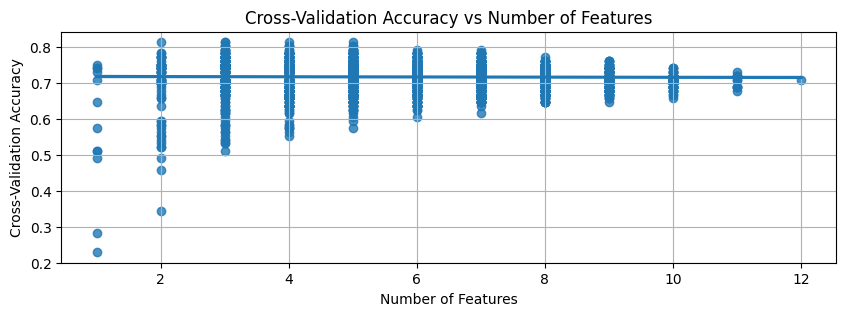

In [136]:
# Scatterplot of CV accuracy vs number of features
plt.figure(figsize=(10, 3))
sns.regplot(data=results_df, x="n_features", y="cv_accuracy", order=1)
plt.title("Cross-Validation Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Accuracy")
plt.grid(True)
plt.show()

<Figure size 1200x1000 with 0 Axes>

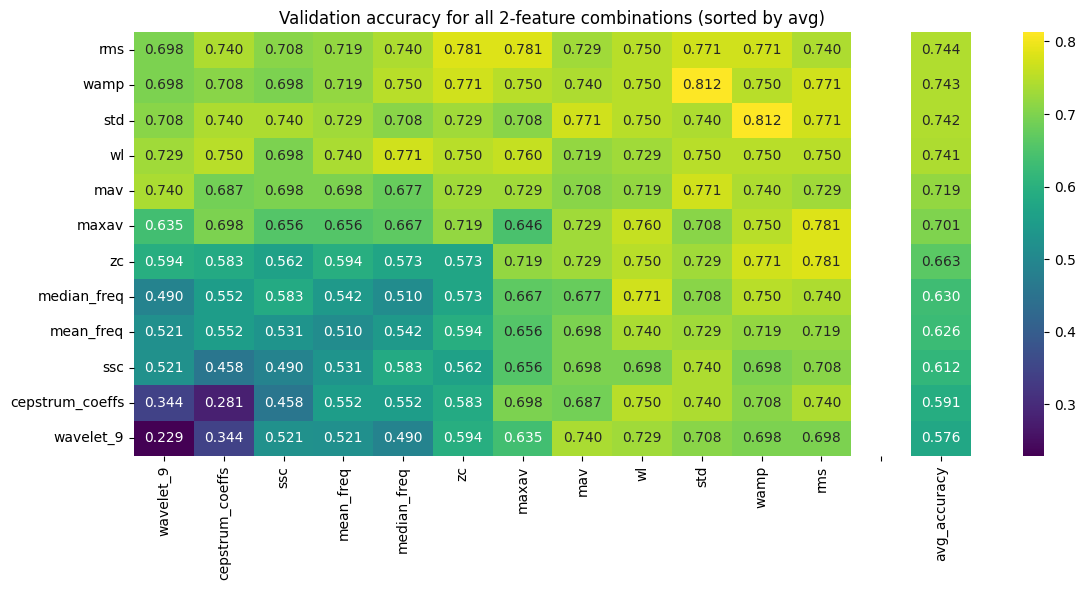

In [132]:
# Visualise the impact of selected features on classification performance, sorted by average accuracy
feature_set_size = 2
subset_df = results_df[results_df['n_features'] == feature_set_size]
plt.figure(figsize=(12, 10))

pair_matrix = pd.DataFrame(np.nan, index=feature_names, columns=feature_names)

for _, row in subset_df.iterrows():
    feature_tuple = row["feature_set"]
    if len(feature_tuple) == 2:
        f1, f2 = feature_tuple
        acc = row["cv_accuracy"]
        pair_matrix.loc[f1, f2] = acc
        pair_matrix.loc[f2, f1] = acc

single_df = results_df[results_df["n_features"] == 1]
for _, row in single_df.iterrows():
    feature_tuple = row["feature_set"]
    if len(feature_tuple) == 1:
        f = feature_tuple[0]
        if f in pair_matrix.index:
            pair_matrix.loc[f, f] = row["cv_accuracy"]

# --- Compute per-feature average accuracy ---
avg_accuracy = pair_matrix.mean(axis=1, skipna=True)

# --- Sort rows by avg accuracy ---
pair_matrix = pair_matrix.loc[avg_accuracy.sort_values(ascending=False).index]

# --- Sort columns BY the same ordering (to maintain symmetry & avoid confusion) ---
pair_matrix = pair_matrix[avg_accuracy.sort_values(ascending=False).index]

# --- Add blank spacer + avg accuracy column ---
pair_matrix[""] = np.nan
pair_matrix["avg_accuracy"] = avg_accuracy.loc[pair_matrix.index]

# final column order (sorted feature columns + spacer + avg)
pair_matrix = pair_matrix.loc[:, list(avg_accuracy.sort_values(ascending=True).index) + ["", "avg_accuracy"]]

# --- Recompute vmin/vmax including new columns ---
vmin = np.nanmin(pair_matrix.values)
vmax = np.nanmax(pair_matrix.values)

# --- Plot ---
plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.heatmap(
    pair_matrix,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    ax=ax,
)
plt.title(f"Validation accuracy for all {feature_set_size}-feature combinations (sorted by avg)")
plt.tight_layout()
plt.show()

/var/folders/5f/6pq8n0ws7c99q7szkxs11zrc0000gn/T/ipykernel_28393/2662869911.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="feature", y="cv_accuracy", data=acc_df, palette="viridis_r", order=order)


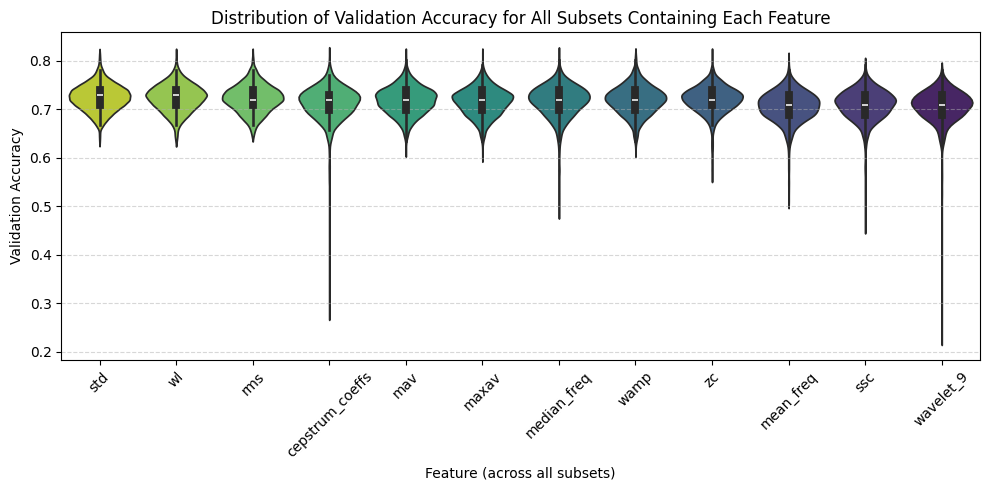

In [137]:
# Aggregate accuracy for every feature across all subsets, then plot as box/strip plot
rows = []
for f in feature_names:
    # Filter rows where the feature is in the tuple
    matching_rows = results_df[results_df["feature_set"].apply(lambda x: f in x)]
    accs = matching_rows["cv_accuracy"]
    rows.extend([{"feature": f, "cv_accuracy": a} for a in accs])

acc_df = pd.DataFrame(rows)

# order features by descending accuracy
order = acc_df.groupby("feature")["cv_accuracy"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.violinplot(x="feature", y="cv_accuracy", data=acc_df, palette="viridis_r", order=order)

plt.xticks(rotation=45)
plt.ylabel("Validation Accuracy")
plt.xlabel("Feature (across all subsets)")
plt.title("Distribution of Validation Accuracy for All Subsets Containing Each Feature")
#plt.ylim(0.4, 0.75)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

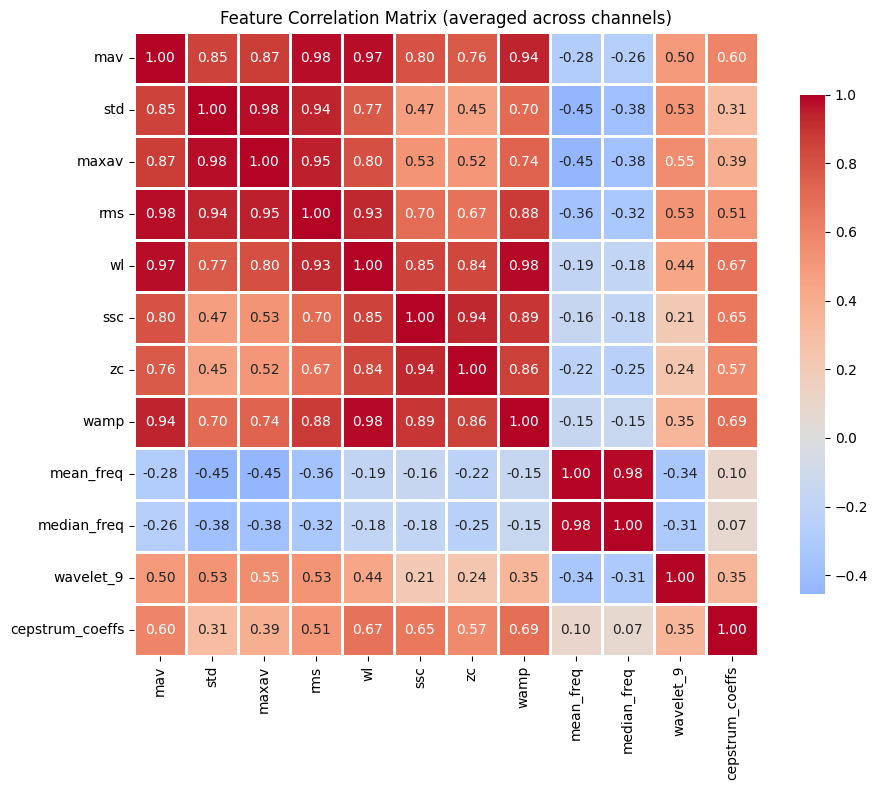


Highly correlated feature pairs (|correlation| > 0.95):
mav <-> rms: 0.978
mav <-> wl: 0.974
std <-> maxav: 0.980
wl <-> wamp: 0.983
mean_freq <-> median_freq: 0.983


In [138]:
# Correlation analysis between features
# Build dataset with all features
# dataset_all = build_dataset_from_precalc(precalc_features, feature_names)

# Create a DataFrame where each column represents the average of each feature across all channels
feature_avg_dict = {}
for idx, fname in enumerate(feature_names):
    start_col = idx * N_CHANNELS
    end_col = start_col + N_CHANNELS
    # Average across channels for each feature
    feature_avg_dict[fname] = dataset[:, start_col:end_col].mean(axis=1)

feature_df = pd.DataFrame(feature_avg_dict)

# Compute correlation matrix
corr_matrix = feature_df.corr()

# Plot correlation matrix'
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix (averaged across channels)")
plt.tight_layout()
plt.show()

threshold = 0.95
# Print highly correlated feature pairs 
print(f"\nHighly correlated feature pairs (|correlation| > {threshold}):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

## Feature Selection / Dimensionality Reduction

### PCA

In [30]:
best_cv_acc_final = 0.8333
test_accuracy_final = 0.7500

PCA Analysis: Using ALL features with fair evaluation
Total features: 230
Using hyperparameters from Step 1: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Using 4-fold cross-validation


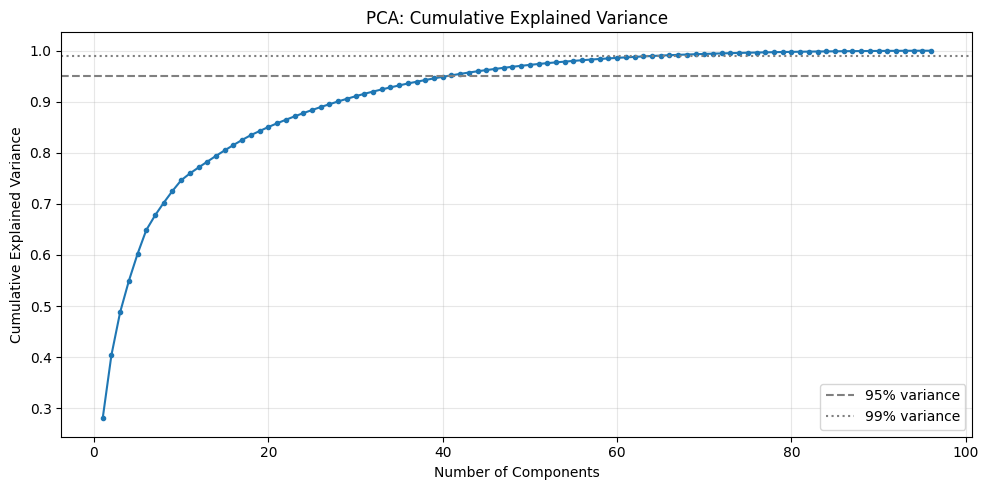

Components for 95% variance: 41
Components for 99% variance: 65
Testing 19 PCA component counts
Components:   5 | CV Acc: 0.6458 ± 0.0691
Components:   6 | CV Acc: 0.6875 ± 0.0691
Components:   9 | CV Acc: 0.6979 ± 0.0949
Components:  10 | CV Acc: 0.7188 ± 0.0800
Components:  14 | CV Acc: 0.6979 ± 0.0616
Components:  19 | CV Acc: 0.6771 ± 0.0800
Components:  24 | CV Acc: 0.6771 ± 0.0994
Components:  28 | CV Acc: 0.7083 ± 0.0589
Components:  33 | CV Acc: 0.7187 ± 0.0744
Components:  38 | CV Acc: 0.6979 ± 0.0949
Components:  41 | CV Acc: 0.7083 ± 0.0884
Components:  43 | CV Acc: 0.6875 ± 0.1334
Components:  48 | CV Acc: 0.6667 ± 0.0659
Components:  52 | CV Acc: 0.6146 ± 0.1036
Components:  57 | CV Acc: 0.6458 ± 0.1083
Components:  62 | CV Acc: 0.6354 ± 0.1117
Components:  65 | CV Acc: 0.5938 ± 0.0800
Components:  67 | CV Acc: 0.6250 ± 0.0659
Components:  72 | CV Acc: 0.6042 ± 0.1083

BEST PCA CONFIGURATION (CONSTRAINED 1-SE RULE)
Number of components: 10
CV accuracy: 0.7188
Comparison to

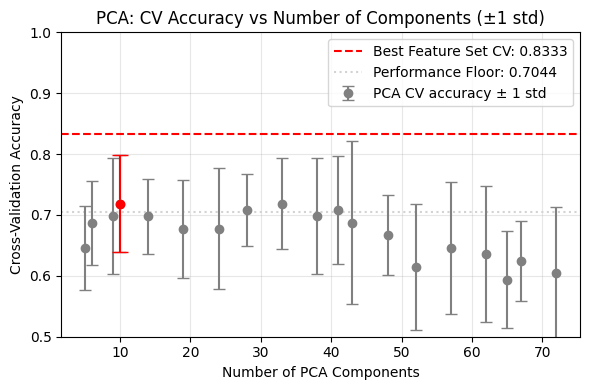

In [34]:
# ==================================================
# PCA Analysis: Fair comparison with best feature set model
# Using CROSS-VALIDATION and TUNED HYPERPARAMETERS
# ==================================================

print("PCA Analysis: Using ALL features with fair evaluation")
print(f"Total features: {X_trainval.shape[1]}")
print(f"Using hyperparameters from Step 1: {best_params_initial}")
print(f"Using {CV_K}-fold cross-validation")

# ==================================================
# PCA VARIANCE ANALYSIS (diagnostic only)
# ==================================================

scaler_diag = StandardScaler()
X_trainval_scaled = scaler_diag.fit_transform(X_trainval)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_trainval_scaled)

cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--", color="gray", label="95% variance")
plt.axhline(0.99, linestyle=":", color="gray", label="99% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

n_comp_95 = int(np.argmax(cumsum_var >= 0.95) + 1)
n_comp_99 = int(np.argmax(cumsum_var >= 0.99) + 1)

custom_values = [6, 10]

print(f"Components for 95% variance: {n_comp_95}")
print(f"Components for 99% variance: {n_comp_99}")

# ==================================================
# PCA COMPONENT SEARCH WITH CROSS-VALIDATION
# ==================================================

n_samples, n_features = X_trainval.shape
samples_per_fold = int(n_samples * (CV_K - 1) / CV_K)
max_components = int(min(samples_per_fold, n_features, 100))

candidate_components = sorted(set(
    list(map(int, np.linspace(5, max_components, 15))) +
    [n_comp_95, n_comp_99] +
    custom_values
))
candidate_components = [int(c) for c in candidate_components if c <= max_components]

print(f"Testing {len(candidate_components)} PCA component counts")

kfold = KFold(
    n_splits=CV_K,
    shuffle=True,
    random_state=RANDOM_STATE
)

pca_results = []

for n_comp in candidate_components:
    n_comp = int(n_comp)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=RANDOM_STATE)),
        ("gbc", GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **best_params_initial
        ))
    ])

    cv = cross_validate(
        pipeline,
        X_trainval,
        y_trainval,
        cv=kfold,
        scoring="accuracy",
        return_train_score=False
    )

    pca_results.append({
        "n_components": n_comp,
        "cv_accuracy": cv["test_score"].mean(),
        "cv_std": cv["test_score"].std()
    })

    print(
        f"Components: {n_comp:3d} | "
        f"CV Acc: {cv['test_score'].mean():.4f} ± {cv['test_score'].std():.4f}"
    )

pca_df = (
    pd.DataFrame(pca_results)
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)

# ==================================================
# MODEL SELECTION (CONSTRAINED 1-SE RULE)
# choose simplest model within 1 standard error of best
# and also within performance floor (98% of best)
# ==================================================

pca_best_mean = float(pca_df.loc[0, "cv_accuracy"])
pca_best_std  = float(pca_df.loc[0, "cv_std"])

# Do not allow models far below the peak
pca_performance_floor = 0.98 * pca_best_mean
pca_eligible = pca_df[
    (pca_df["cv_accuracy"] >= pca_best_mean - pca_best_std) &
    (pca_df["cv_accuracy"] >= pca_performance_floor)
]

pca_best_n_components = int(
    pca_eligible.sort_values("n_components").iloc[0]["n_components"]
)

best_pca_entry = pca_df[pca_df["n_components"] == pca_best_n_components].iloc[0]
print(f"\n{'='*60}")
print("BEST PCA CONFIGURATION (CONSTRAINED 1-SE RULE)")
print(f"{'='*60}")
print(f"Number of components: {pca_best_n_components}")
print(f"CV accuracy: {best_pca_entry['cv_accuracy']:.4f}")
print(
    f"Comparison to Step 3 CV accuracy: "
    f"{best_pca_entry['cv_accuracy'] - best_cv_acc_final:+.4f}"
)
print(f"{'='*60}")

# ==================================================
# FINAL MODEL: TRAIN ON FULL TRAINVAL
# ==================================================

pipeline_pca_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=pca_best_n_components, random_state=RANDOM_STATE)),
    ("gbc", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **best_params_initial
    ))
])

pipeline_pca_final.fit(X_trainval, y_trainval)

# ==================================================
# FINAL TEST EVALUATION
# ==================================================

y_test_pred_pca = pipeline_pca_final.predict(X_test)
test_acc_pca = accuracy_score(y_test, y_test_pred_pca)
cm_pca = confusion_matrix(y_test, y_test_pred_pca)

print(f"\n{'='*60}")
print("FINAL TEST RESULTS COMPARISON")
print(f"{'='*60}")
print(f"PCA Model:")
print(f"  - CV accuracy:   {best_pca_entry['cv_accuracy']:.4f}")
print(f"  - Test accuracy: {test_acc_pca:.4f}")
print(f"  - Components:    {pca_best_n_components}")
print(f"\nBest Feature Set Model:")
print(f"  - CV accuracy:   {best_cv_acc_final:.4f}")
print(f"  - Test accuracy: {test_accuracy_final:.4f}")
print(f"\nDifference (PCA - Feature Selection):")
print(f"  - CV:   {best_pca_entry['cv_accuracy'] - best_cv_acc_final:+.4f}")
print(f"  - Test: {test_acc_pca - test_accuracy_final:+.4f}")
print(f"{'='*60}")



# ==================================================
# VISUALIZATION: CV ACCURACY WITH ERROR BARS
# ==================================================

plt.figure(figsize=(6, 4)) 

# Highlight best feature set CV accuracy
plt.axhline(
    best_cv_acc_final,
    color="red",
    linestyle="--",
    label=f"Best Feature Set CV: {best_cv_acc_final:.4f}"
)


# Highlight performance floor cutoff
plt.axhline(
    pca_performance_floor,
    color="lightgray",
    linestyle="dotted",
    label=f"Performance Floor: {pca_performance_floor:.4f}"
)

# Plot PCA CV accuracy with error bars without
plt.errorbar(
    x=pca_df["n_components"],
    y=pca_df["cv_accuracy"],
    yerr=pca_df["cv_std"],
    fmt="o",
    capsize=4,
    label="PCA CV accuracy ± 1 std",
    color="grey"
)

# Highlight selected number of components by colouring the datapoint
pca_best_point = pca_df[pca_df["n_components"] == pca_best_n_components]
plt.errorbar(
    x=pca_best_n_components,
    y=pca_best_point["cv_accuracy"],
    yerr=pca_best_point["cv_std"],
    fmt="o",
    capsize=6,
    color="red",
    label="_hidden"
    #label=f"Selected PCA Components: {pca_best_n_components}"
)


plt.xlabel("Number of PCA Components")
plt.ylabel("Cross-Validation Accuracy")
plt.title("PCA: CV Accuracy vs Number of Components (±1 std)")
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# SAVE RESULTS
# ==================================================

pca_summary = pd.DataFrame([{
    "method": "PCA",
    "n_original_features": X_trainval.shape[1],
    "n_pca_components": pca_best_n_components,
    "cv_accuracy_pca": best_pca_entry["cv_accuracy"],
    "cv_std_pca": best_pca_entry["cv_std"],
    "test_accuracy_pca": test_acc_pca,
    "cv_accuracy_best_features": best_cv_acc_final,
    "test_accuracy_best_features": test_accuracy_final,
    "cv_improvement": best_pca_entry["cv_accuracy"] - best_cv_acc_final,
    "test_improvement": test_acc_pca - test_accuracy_final,
    "hyperparameters": str(best_params_initial)
}])

pca_summary.to_csv("results/pca_results.csv", index=False)
pca_df.to_csv("results/pca_component_search.csv", index=False)



### ICA

In [35]:
from sklearn.decomposition import FastICA

# ==================================================
# ICA Analysis: Fair comparison with best feature set model
# Using CROSS-VALIDATION and TUNED HYPERPARAMETERS
# ==================================================

print("ICA Analysis: Using ALL features with fair evaluation")
print(f"Total features: {X_trainval.shape[1]}")
print(f"Using hyperparameters from Step 1: {best_params_initial}")
print(f"Using {CV_K}-fold cross-validation")

# ==================================================
# ICA DIAGNOSTIC ANALYSIS (kurtosis, diagnostic only)
# ==================================================

scaler_diag = StandardScaler()
X_trainval_scaled = scaler_diag.fit_transform(X_trainval)

ica_full = FastICA(
    random_state=RANDOM_STATE,
    whiten="unit-variance",
    max_iter=2000,
    tol=1e-4
)

X_ica_full = ica_full.fit_transform(X_trainval_scaled)

# Mean absolute kurtosis per component
kurtosis_vals = np.mean(np.abs(pd.DataFrame(X_ica_full).kurtosis()))

print(f"Mean absolute kurtosis across ICA components: {kurtosis_vals:.4f}")

# ==================================================
# ICA COMPONENT SEARCH WITH CROSS-VALIDATION
# ==================================================

n_samples, n_features = X_trainval.shape
samples_per_fold = int(n_samples * (CV_K - 1) / CV_K)
max_components = int(min(samples_per_fold, n_features, 100))

custom_values = [6, 10]

candidate_components = sorted(set(
    list(map(int, np.linspace(5, max_components, 15))) +
    custom_values
))
candidate_components = [int(c) for c in candidate_components if c <= max_components]

print(f"Testing {len(candidate_components)} ICA component counts")

kfold = KFold(
    n_splits=CV_K,
    shuffle=True,
    random_state=RANDOM_STATE
)

ica_results = []

for n_comp in candidate_components:
    n_comp = int(n_comp)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ica", FastICA(
            n_components=n_comp,
            random_state=RANDOM_STATE,
            whiten="unit-variance",
            max_iter=2000,
            tol=1e-4
        )),
        ("gbc", GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **best_params_initial
        ))
    ])

    cv = cross_validate(
        pipeline,
        X_trainval,
        y_trainval,
        cv=kfold,
        scoring="accuracy",
        return_train_score=False
    )

    ica_results.append({
        "n_components": n_comp,
        "cv_accuracy": cv["test_score"].mean(),
        "cv_std": cv["test_score"].std()
    })

    print(
        f"Components: {n_comp:3d} | "
        f"CV Acc: {cv['test_score'].mean():.4f} ± {cv['test_score'].std():.4f}"
    )

ica_df = (
    pd.DataFrame(ica_results)
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)

# ==================================================
# MODEL SELECTION (CONSTRAINED 1-SE RULE)
# ==================================================

ica_best_mean = float(ica_df.loc[0, "cv_accuracy"])
ica_best_std  = float(ica_df.loc[0, "cv_std"])

ica_performance_floor = 0.98 * ica_best_mean

ica_eligible = ica_df[
    (ica_df["cv_accuracy"] >= ica_best_mean - ica_best_std) &
    (ica_df["cv_accuracy"] >= ica_performance_floor)
]

ica_best_n_components = int(
    ica_eligible.sort_values("n_components").iloc[0]["n_components"]
)

best_ica_entry = ica_df[ica_df["n_components"] == ica_best_n_components].iloc[0]

print(f"\n{'='*60}")
print("BEST ICA CONFIGURATION (CONSTRAINED 1-SE RULE)")
print(f"{'='*60}")
print(f"Number of components: {ica_best_n_components}")
print(f"CV accuracy: {best_ica_entry['cv_accuracy']:.4f}")
print(
    f"Comparison to Step 3 CV accuracy: "
    f"{best_ica_entry['cv_accuracy'] - best_cv_acc_final:+.4f}"
)
print(f"{'='*60}")

# ==================================================
# FINAL MODEL: TRAIN ON FULL TRAINVAL
# ==================================================

pipeline_ica_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ica", FastICA(
        n_components=ica_best_n_components,
        random_state=RANDOM_STATE,
        whiten="unit-variance",
        max_iter=2000,
        tol=1e-4
    )),
    ("gbc", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **best_params_initial
    ))
])

pipeline_ica_final.fit(X_trainval, y_trainval)

# ==================================================
# FINAL TEST EVALUATION
# ==================================================

y_test_pred_ica = pipeline_ica_final.predict(X_test)
test_acc_ica = accuracy_score(y_test, y_test_pred_ica)
cm_ica = confusion_matrix(y_test, y_test_pred_ica)

print(f"\n{'='*60}")
print("FINAL TEST RESULTS COMPARISON")
print(f"{'='*60}")
print(f"ICA Model:")
print(f"  - CV accuracy:   {best_ica_entry['cv_accuracy']:.4f}")
print(f"  - Test accuracy: {test_acc_ica:.4f}")
print(f"  - Components:    {ica_best_n_components}")
print(f"\nBest Feature Set Model:")
print(f"  - CV accuracy:   {best_cv_acc_final:.4f}")
print(f"  - Test accuracy: {test_accuracy_final:.4f}")
print(f"\nDifference (ICA - Feature Selection):")
print(f"  - CV:   {best_ica_entry['cv_accuracy'] - best_cv_acc_final:+.4f}")
print(f"  - Test: {test_acc_ica - test_accuracy_final:+.4f}")
print(f"{'='*60}")

# ==================================================
# SAVE RESULTS
# ==================================================

ica_summary = pd.DataFrame([{
    "method": "ICA",
    "n_original_features": X_trainval.shape[1],
    "n_ica_components": ica_best_n_components,
    "cv_accuracy_ica": best_ica_entry["cv_accuracy"],
    "cv_std_ica": best_ica_entry["cv_std"],
    "test_accuracy_ica": test_acc_ica,
    "cv_accuracy_best_features": best_cv_acc_final,
    "test_accuracy_best_features": test_accuracy_final,
    "cv_improvement": best_ica_entry["cv_accuracy"] - best_cv_acc_final,
    "test_improvement": test_acc_ica - test_accuracy_final,
    "hyperparameters": str(best_params_initial)
}])

ica_summary.to_csv("results/ica_results.csv", index=False)
ica_df.to_csv("results/ica_component_search.csv", index=False)

ICA Analysis: Using ALL features with fair evaluation
Total features: 230
Using hyperparameters from Step 1: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Using 4-fold cross-validation


/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Mean absolute kurtosis across ICA components: 89.2796
Testing 17 ICA component counts
Components:   5 | CV Acc: 0.6146 ± 0.0616


/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Components:   6 | CV Acc: 0.5938 ± 0.1036


...

Components:  10 | CV Acc: 0.7708 ± 0.0361
Components:  14 | CV Acc: 0.7396 ± 0.0744
Components:  19 | CV Acc: 0.6875 ± 0.0859
Components:  24 | CV Acc: 0.6354 ± 0.0683
Components:  28 | CV Acc: 0.6875 ± 0.1233
Components:  33 | CV Acc: 0.5312 ± 0.1192
Components:  38 | CV Acc: 0.5000 ± 0.0977
Components:  43 | CV Acc: 0.4271 ± 0.1155
Components:  48 | CV Acc: 0.4792 ± 0.0691
Components:  52 | CV Acc: 0.4167 ± 0.0780
Components:  57 | CV Acc: 0.3333 ± 0.0295
Components:  62 | CV Acc: 0.3333 ± 0.0417
Components:  67 | CV Acc: 0.2292 ± 0.0466


/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/2

Components:  72 | CV Acc: 0.0312 ± 0.0345

BEST ICA CONFIGURATION (CONSTRAINED 1-SE RULE)
Number of components: 9
CV accuracy: 0.7708
Comparison to Step 3 CV accuracy: -0.0625


/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(



FINAL TEST RESULTS COMPARISON
ICA Model:
  - CV accuracy:   0.7708
  - Test accuracy: 0.8750
  - Components:    9

Best Feature Set Model:
  - CV accuracy:   0.8333
  - Test accuracy: 0.7500

Difference (ICA - Feature Selection):
  - CV:   -0.0625
  - Test: +0.1250


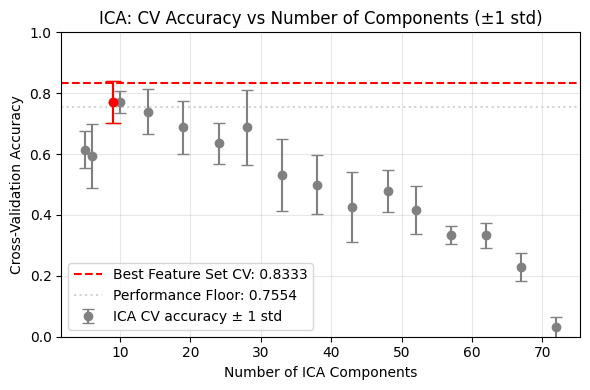

In [36]:

# ==================================================
# VISUALIZATION: CV ACCURACY WITH ERROR BARS
# ==================================================

plt.figure(figsize=(6, 4))

plt.axhline(
    best_cv_acc_final,
    linestyle="--",
    label=f"Best Feature Set CV: {best_cv_acc_final:.4f}",
    color="red"
)

plt.axhline(
    ica_performance_floor,
    linestyle="dotted",
    label=f"Performance Floor: {ica_performance_floor:.4f}",
    color="lightgray"
)

plt.errorbar(
    x=ica_df["n_components"],
    y=ica_df["cv_accuracy"],
    yerr=ica_df["cv_std"],
    fmt="o",
    capsize=4,
    label="ICA CV accuracy ± 1 std",
    color="grey"
)

best_point = ica_df[ica_df["n_components"] == ica_best_n_components]
plt.errorbar(
    x=ica_best_n_components,
    y=best_point["cv_accuracy"],
    yerr=best_point["cv_std"],
    fmt="o",
    capsize=6,
    color="red",
    label="_hidden"
)

plt.xlabel("Number of ICA Components")
plt.ylabel("Cross-Validation Accuracy")
plt.title("ICA: CV Accuracy vs Number of Components (±1 std)")
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


### MI

Mutual Information Analysis: Using ALL features with fair evaluation
Total features: 230
Using hyperparameters from Step 1: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Using 4-fold cross-validation


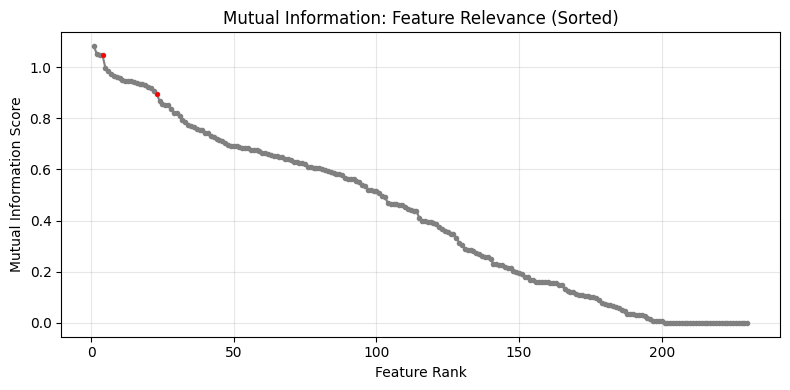

In [86]:
# ==================================================
# MUTUAL INFORMATION ANALYSIS: Fair comparison
# Using CROSS-VALIDATION and TUNED HYPERPARAMETERS
# ==================================================

print("Mutual Information Analysis: Using ALL features with fair evaluation")
print(f"Total features: {X_trainval.shape[1]}")
print(f"Using hyperparameters from Step 1: {best_params_initial}")
print(f"Using {CV_K}-fold cross-validation")

# ==================================================
# MI DIAGNOSTIC ANALYSIS (feature relevance only)
# ==================================================

scaler_diag = StandardScaler()
X_trainval_scaled = scaler_diag.fit_transform(X_trainval)

mi_scores = mutual_info_classif(
    X_trainval_scaled,
    y_trainval,
    random_state=RANDOM_STATE
)


mi_df_diag = pd.DataFrame({
    "feature_index": np.arange(len(mi_scores)),
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(mi_scores) + 1),
    np.sort(mi_scores)[::-1],
    marker="o",
    markersize=3,
    color="grey"
)

# Highlight specific points
mi_custom_values = [4, 23]
plt.scatter(
    mi_custom_values,
    mi_df_diag.iloc[[idx - 1 for idx in mi_custom_values]]["mutual_information"],
    marker="o",
    s=6,
    color="red",
    label=f"Feature Rank {mi_custom_values}",
    zorder=100
)

plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information Score")
plt.title("Mutual Information: Feature Relevance (Sorted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [61]:
# ==================================================
# MI FEATURE COUNT SEARCH WITH CROSS-VALIDATION
# ==================================================

# Determine maximum feasible features to select
n_samples, n_features = X_trainval.shape
samples_per_fold = int(n_samples * (CV_K - 1) / CV_K) 
max_features = int(min(samples_per_fold, n_features, 100))

# Custom values based on previous graphic

candidate_k = sorted(set(
    list(map(int, np.linspace(5, max_features, 15))) +
    mi_custom_values
))
candidate_k = [int(k) for k in candidate_k if k <= max_features]

print(f"Testing {len(candidate_k)} feature counts")

kfold = KFold(
    n_splits=CV_K,
    shuffle=True,
    random_state=RANDOM_STATE
)

mi_results = []

for k in candidate_k:
    k = int(k)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("mi", SelectKBest(
            score_func=mutual_info_classif,
            k=k
        )),
        ("gbc", GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **best_params_initial
        ))
    ])

    cv = cross_validate(
        pipeline,
        X_trainval,
        y_trainval,
        cv=kfold,
        scoring="accuracy",
        return_train_score=False
    )

    mi_results.append({
        "n_features": k,
        "cv_accuracy": cv["test_score"].mean(),
        "cv_std": cv["test_score"].std()
    })

    print(
        f"Features: {k:3d} | "
        f"CV Acc: {cv['test_score'].mean():.4f} ± {cv['test_score'].std():.4f}"
    )

mi_df = (
    pd.DataFrame(mi_results)
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)

# ==================================================
# MODEL SELECTION (CONSTRAINED 1-SE RULE)
# ==================================================

mi_best_mean = float(mi_df.loc[0, "cv_accuracy"])
mi_best_std  = float(mi_df.loc[0, "cv_std"])

mi_performance_floor = 0.98 * mi_best_mean

mi_eligible = mi_df[
    (mi_df["cv_accuracy"] >= mi_best_mean - mi_best_std) &
    (mi_df["cv_accuracy"] >= mi_performance_floor)
]

mi_best_k_features = int(
    mi_eligible.sort_values("n_features").iloc[0]["n_features"]
)

best_mi_entry = mi_df[mi_df["n_features"] == mi_best_k_features].iloc[0]

print(f"\n{'='*60}")
print("BEST MUTUAL INFORMATION CONFIGURATION (CONSTRAINED 1-SE RULE)")
print(f"{'='*60}")
print(f"Number of selected features: {mi_best_k_features}")
print(f"CV accuracy: {best_mi_entry['cv_accuracy']:.4f}")
print(
    f"Comparison to Step 3 CV accuracy: "
    f"{best_mi_entry['cv_accuracy'] - best_cv_acc_final:+.4f}"
)
print(f"{'='*60}")

# ==================================================
# FINAL MODEL: TRAIN ON FULL TRAINVAL
# ==================================================

pipeline_mi_final = Pipeline([
    ("scaler", StandardScaler()),
    ("mi", SelectKBest(
        score_func=mutual_info_classif,
        k=mi_best_k_features
    )),
    ("gbc", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **best_params_initial
    ))
])

pipeline_mi_final.fit(X_trainval, y_trainval)

# ==================================================
# FINAL TEST EVALUATION
# ==================================================

y_test_pred_mi = pipeline_mi_final.predict(X_test)
test_acc_mi = accuracy_score(y_test, y_test_pred_mi)
cm_mi = confusion_matrix(y_test, y_test_pred_mi)

print(f"\n{'='*60}")
print("FINAL TEST RESULTS COMPARISON")
print(f"{'='*60}")
print(f"Mutual Information Model:")
print(f"  - CV accuracy:   {best_mi_entry['cv_accuracy']:.4f}")
print(f"  - Test accuracy: {test_acc_mi:.4f}")
print(f"  - Features:      {mi_best_k_features}")
print(f"\nBest Feature Set Model:")
print(f"  - CV accuracy:   {best_cv_acc_final:.4f}")
print(f"  - Test accuracy: {test_accuracy_final:.4f}")
print(f"\nDifference (MI - Feature Selection):")
print(f"  - CV:   {best_mi_entry['cv_accuracy'] - best_cv_acc_final:+.4f}")
print(f"  - Test: {test_acc_mi - test_accuracy_final:+.4f}")
print(f"{'='*60}")


# ==================================================
# SAVE RESULTS
# ==================================================

mi_summary = pd.DataFrame([{
    "method": "Mutual Information",
    "n_original_features": X_trainval.shape[1],
    "n_selected_features": mi_best_k_features,
    "cv_accuracy_mi": best_mi_entry["cv_accuracy"],
    "cv_std_mi": best_mi_entry["cv_std"],
    "test_accuracy_mi": test_acc_mi,
    "cv_accuracy_best_features": best_cv_acc_final,
    "test_accuracy_best_features": test_accuracy_final,
    "cv_improvement": best_mi_entry["cv_accuracy"] - best_cv_acc_final,
    "test_improvement": test_acc_mi - test_accuracy_final,
    "hyperparameters": str(best_params_initial)
}])

mi_summary.to_csv("results/mi_results.csv", index=False)
mi_df.to_csv("results/mi_feature_search.csv", index=False)

72 230 72
Testing 16 feature counts
Features:   5 | CV Acc: 0.2188 ± 0.1155
Features:   9 | CV Acc: 0.4271 ± 0.0541
Features:  14 | CV Acc: 0.6458 ± 0.0751
Features:  19 | CV Acc: 0.6562 ± 0.0949
Features:  23 | CV Acc: 0.6979 ± 0.0454
Features:  24 | CV Acc: 0.6771 ± 0.0345
Features:  28 | CV Acc: 0.7292 ± 0.0691
Features:  33 | CV Acc: 0.7188 ± 0.0616
Features:  38 | CV Acc: 0.7292 ± 0.0955
Features:  43 | CV Acc: 0.7813 ± 0.0541
Features:  48 | CV Acc: 0.7917 ± 0.0932
Features:  52 | CV Acc: 0.7604 ± 0.0345
Features:  57 | CV Acc: 0.7396 ± 0.0454
Features:  62 | CV Acc: 0.7500 ± 0.0295
Features:  67 | CV Acc: 0.7812 ± 0.0454
Features:  72 | CV Acc: 0.7604 ± 0.0800

BEST MUTUAL INFORMATION CONFIGURATION (CONSTRAINED 1-SE RULE)
Number of selected features: 43
CV accuracy: 0.7813
Comparison to Step 3 CV accuracy: -0.0520

FINAL TEST RESULTS COMPARISON
Mutual Information Model:
  - CV accuracy:   0.7813
  - Test accuracy: 0.7917
  - Features:      43

Best Feature Set Model:
  - CV accu

Building datasets for S27 and S1–S26...
S27: X shape = (120, 230), classes = 12
Train pool S1–S26: X shape = (3120, 230)

S27 Generalization Comparison
                       setting  train_samples  test_samples  accuracy
Train S27 / Test S27 (holdout)             96            24  0.708333
 Train S1–S26 / Test S27 (all)           3120           120  0.258333


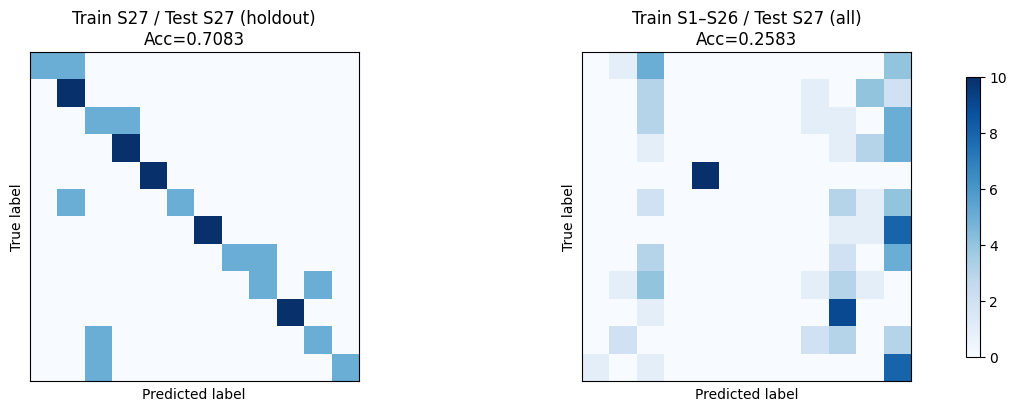

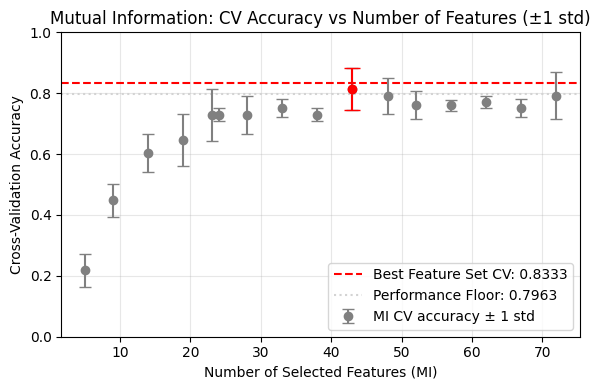

In [46]:

# ==================================================
# VISUALIZATION: CV ACCURACY WITH ERROR BARS
# ==================================================

plt.figure(figsize=(6, 4))

plt.axhline(
    best_cv_acc_final,
    linestyle="--",
    label=f"Best Feature Set CV: {best_cv_acc_final:.4f}",
    color="red"
)

plt.axhline(
    mi_performance_floor,
    linestyle="dotted",
    label=f"Performance Floor: {mi_performance_floor:.4f}",
    color="lightgray"
)

plt.errorbar(
    x=mi_df["n_features"],
    y=mi_df["cv_accuracy"],
    yerr=mi_df["cv_std"],
    fmt="o",
    capsize=4,
    label="MI CV accuracy ± 1 std",
    color="grey"
)

best_point = mi_df[mi_df["n_features"] == mi_best_k_features]
plt.errorbar(
    x=mi_best_k_features,
    y=best_point["cv_accuracy"],
    yerr=best_point["cv_std"],
    fmt="o",
    capsize=6,
    color="red",
    label="_hidden"
)

plt.xlabel("Number of Selected Features (MI)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Mutual Information: CV Accuracy vs Number of Features (±1 std)")
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

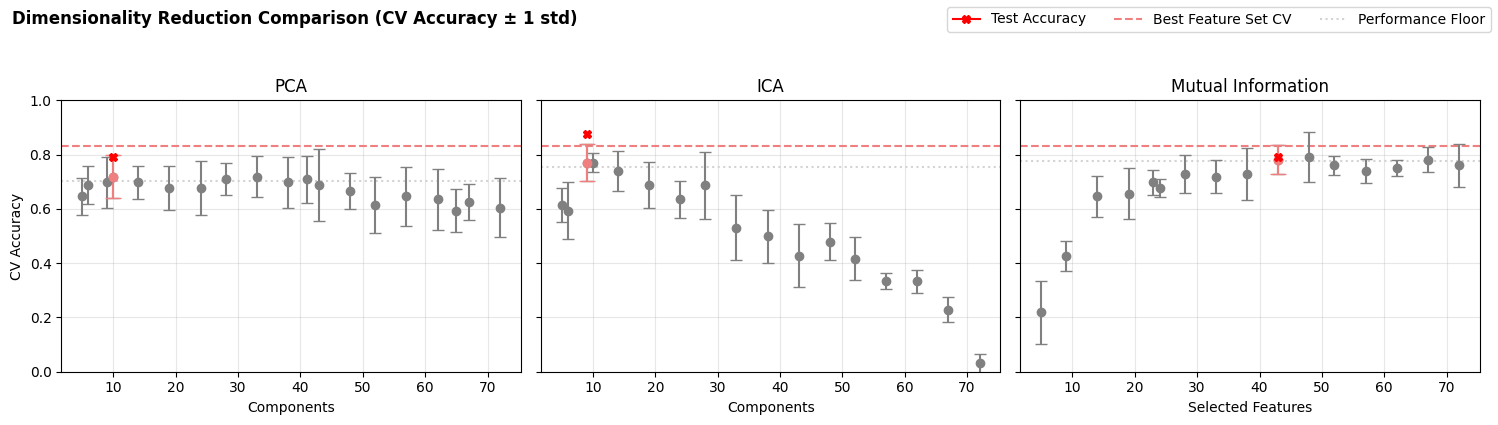

In [73]:
# ==================================================
# COMPARISON PLOT: PCA vs ICA vs Mutual Information
# ==================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

ylim = (0.0, 1.0)

# ------------------
# PCA
# ------------------

# Testing accuracy point
axes[0].plot(
    pca_best_n_components,
    test_acc_pca,
    marker="X",
    markersize=6,
    color="red",
    label="Test Accuracy",
    zorder=100
)

axes[0].axhline(
    best_cv_acc_final,
    linestyle="dashed",
    color="lightcoral",
    label="Best Feature Set CV"
)

axes[0].axhline(
    pca_performance_floor,
    linestyle="dotted",
    color="lightgray",
    label="Performance Floor"
)

axes[0].errorbar(
    pca_df["n_components"],
    pca_df["cv_accuracy"],
    yerr=pca_df["cv_std"],
    fmt="o",
    capsize=4,
    color="grey"
)

best_pca_point = pca_df[pca_df["n_components"] == pca_best_n_components]
axes[0].errorbar(
    pca_best_n_components,
    best_pca_point["cv_accuracy"],
    yerr=best_pca_point["cv_std"],
    fmt="o",
    capsize=6,
    color="lightcoral"
)

axes[0].set_title("PCA")
axes[0].set_xlabel("Components")
axes[0].set_ylabel("CV Accuracy")
axes[0].set_ylim(ylim)
axes[0].grid(True, alpha=0.3)

# ------------------
# ICA
# ------------------

# Testing accuracy point
axes[1].plot(
    ica_best_n_components,
    test_acc_ica,
    marker="X",
    markersize=6,
    color="red",
    label="_ICA Test Accuracy",
    zorder=100
)


axes[1].axhline(
    best_cv_acc_final,
    linestyle="dashed",
    color="lightcoral"
)

axes[1].axhline(
    ica_performance_floor,
    linestyle="dotted",
    color="lightgray"
)

axes[1].errorbar(
    ica_df["n_components"],
    ica_df["cv_accuracy"],
    yerr=ica_df["cv_std"],
    fmt="o",
    capsize=4,
    color="grey"
)

best_ica_point = ica_df[ica_df["n_components"] == ica_best_n_components]
axes[1].errorbar(
    ica_best_n_components,
    best_ica_point["cv_accuracy"],
    yerr=best_ica_point["cv_std"],
    fmt="o",
    capsize=6,
    color="lightcoral"
)

axes[1].set_title("ICA")
axes[1].set_xlabel("Components")
axes[1].set_ylim(ylim)
axes[1].grid(True, alpha=0.3)

# ------------------
# Mutual Information
# ------------------

# Testing accuracy point on top of CV plot
axes[2].plot(
    mi_best_k_features,
    test_acc_mi,
    marker="X",
    markersize=6,
    color="red",
    label="_MI Test Accuracy",
    zorder=100
)

axes[2].axhline(
    best_cv_acc_final,
    linestyle="dashed",
    color="lightcoral"
)

axes[2].axhline(
    mi_performance_floor,
    linestyle="dotted",
    color="lightgray"
)

axes[2].errorbar(
    mi_df["n_features"],
    mi_df["cv_accuracy"],
    yerr=mi_df["cv_std"],
    fmt="o",
    capsize=4,
    color="grey"
)

best_mi_point = mi_df[mi_df["n_features"] == mi_best_k_features]
axes[2].errorbar(
    mi_best_k_features,
    best_mi_point["cv_accuracy"],
    yerr=best_mi_point["cv_std"],
    fmt="o",
    capsize=6,
    color="lightcoral"
)

axes[2].set_title("Mutual Information")
axes[2].set_xlabel("Selected Features")
axes[2].set_ylim(ylim)
axes[2].grid(True, alpha=0.3)


# ------------------
# Shared legend
# ------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=3)

plt.suptitle(
    "Dimensionality Reduction Comparison (CV Accuracy ± 1 std)",
    # bold title
    fontweight="bold",
    x=0.2,
    y=1.05,
)

plt.tight_layout()
plt.show()